In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix,

    f1_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.drop(
    columns=["RowNumber", "CustomerId", "Surname"],
    inplace=True
)

In [8]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

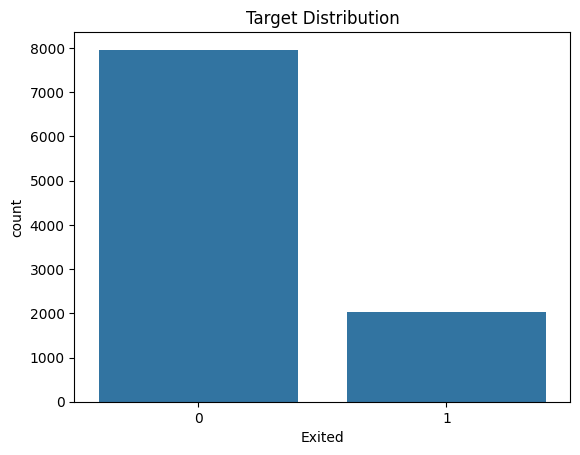

In [10]:
sns.countplot(
    x="Exited",
    data=df
)

plt.title("Target Distribution")

plt.show()

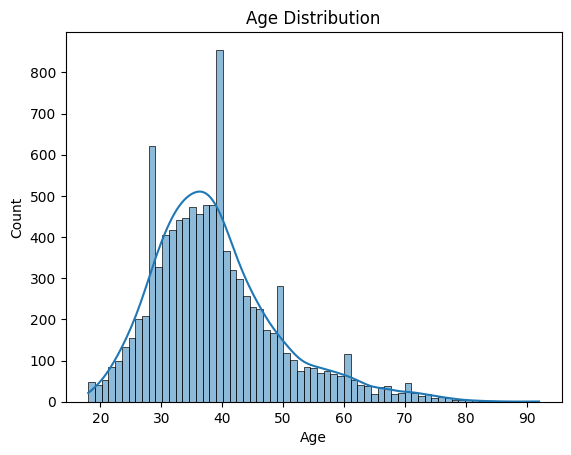

In [11]:
sns.histplot(
    df["Age"],
    kde=True
)

plt.title("Age Distribution")

plt.show()

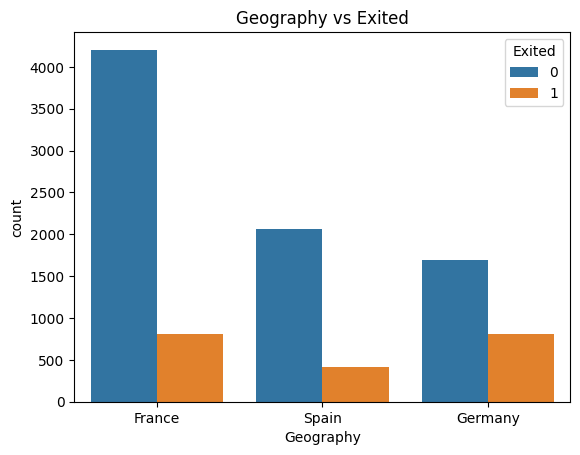

In [12]:
sns.countplot(
    x="Geography",
    hue="Exited",
    data=df
)

plt.title("Geography vs Exited")

plt.show()

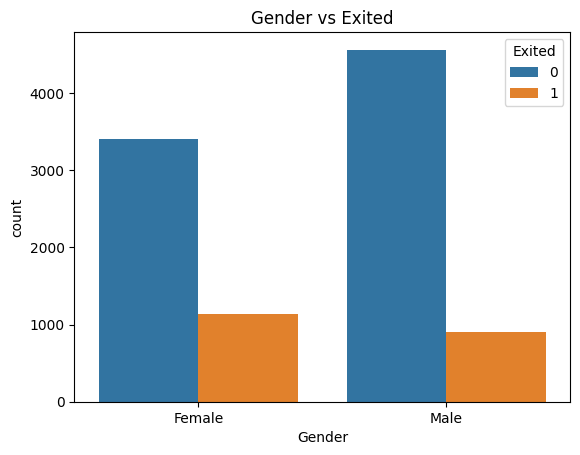

In [13]:
sns.countplot(
    x="Gender",
    hue="Exited",
    data=df
)

plt.title("Gender vs Exited")

plt.show()

In [14]:
df["BalancePerProduct"] = (
    df["Balance"] /
    (df["NumOfProducts"] + 1)
)

In [15]:
df["AgeGroup"] = pd.cut(

    df["Age"],

    bins=[18,30,40,50,60,100],

    labels=[
        "Young",
        "Adult",
        "MidAge",
        "Senior",
        "Old"
    ]
)

In [16]:
df["TenureGroup"] = pd.cut(

    df["Tenure"],

    bins=[0,3,6,10],

    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [17]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalancePerProduct,AgeGroup,TenureGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.00,MidAge,Low
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41903.93,MidAge,Low
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,39915.20,MidAge,High
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.00,Adult,Low
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,62755.41,MidAge,Low


In [18]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [20]:
num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

num_cols

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'BalancePerProduct'],
      dtype='str')

In [21]:
cat_cols = X.select_dtypes(
    include=["object", "category"]
).columns

cat_cols

Index(['Geography', 'Gender', 'AgeGroup', 'TenureGroup'], dtype='str')

In [22]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [23]:
num_pipeline = Pipeline([

    ("imputer",
     SimpleImputer(strategy="median")),

    ("scaler",
     StandardScaler())
])

In [24]:
cat_pipeline = Pipeline([

    ("imputer",
     SimpleImputer(strategy="most_frequent")),

    ("encoder",
     OneHotEncoder(handle_unknown="ignore"))
])

In [25]:
preprocessor = ColumnTransformer([

    ("num",
     num_pipeline,
     num_cols),

    ("cat",
     cat_pipeline,
     cat_cols)
])

In [26]:
lr_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", LogisticRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

print(
    accuracy_score(y_test, lr_pred)
)

0.8305


In [27]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1593
           1       0.70      0.29      0.41       407

    accuracy                           0.83      2000
   macro avg       0.77      0.63      0.65      2000
weighted avg       0.81      0.83      0.80      2000



In [30]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

print(cm)

[[1544   49]
 [ 290  117]]


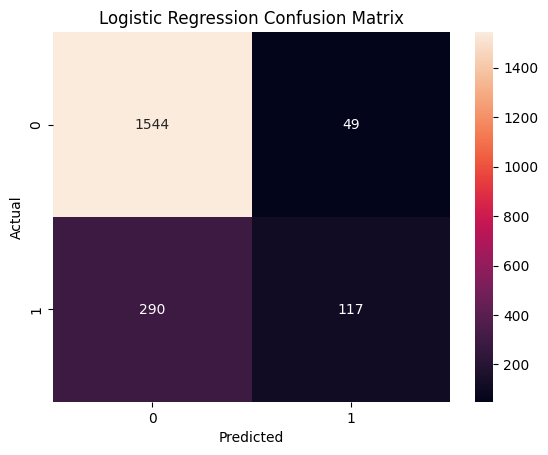

In [31]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Accuracy Score:

0.856

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1593
           1       0.79      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000


Confusion Matrix:

[[1549   44]
 [ 244  163]]


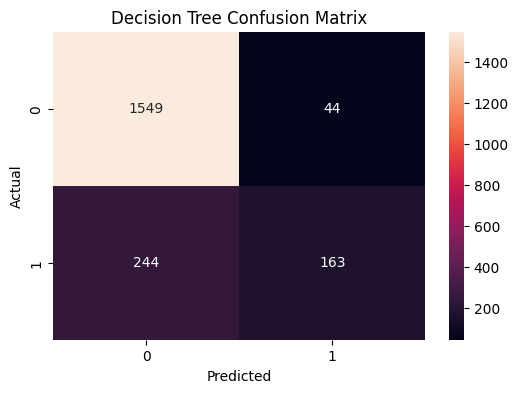

In [32]:


dt_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

# TRAIN MODEL
dt_pipeline.fit(X_train, y_train)

# PREDICTIONS
dt_pred = dt_pipeline.predict(X_test)

# ACCURACY
print("Accuracy Score:\n")
print(
    accuracy_score(y_test, dt_pred)
)

# CLASSIFICATION REPORT
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        dt_pred
    )
)

# CONFUSION MATRIX
dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

print("\nConfusion Matrix:\n")
print(dt_cm)

# CONFUSION MATRIX HEATMAP
plt.figure(figsize=(6,4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Accuracy Score:

0.868

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.85      0.43      0.57       407

    accuracy                           0.87      2000
   macro avg       0.86      0.70      0.75      2000
weighted avg       0.87      0.87      0.85      2000


Confusion Matrix:

[[1562   31]
 [ 233  174]]


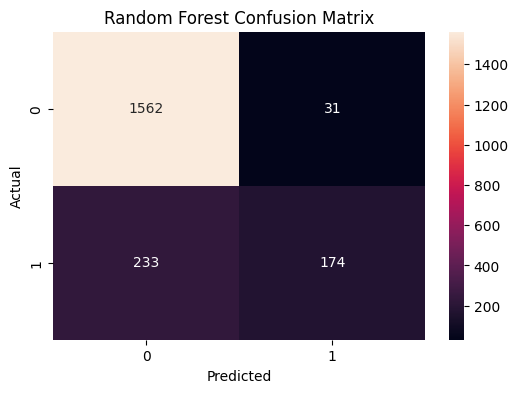

In [33]:
# RANDOM FOREST PIPELINE

rf_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", RandomForestClassifier(

        n_estimators=200,

        max_depth=10,

        random_state=42
    ))
])

# TRAIN MODEL
rf_pipeline.fit(X_train, y_train)

# PREDICTIONS
rf_pred = rf_pipeline.predict(X_test)

# ACCURACY
print("Accuracy Score:\n")

print(
    accuracy_score(y_test, rf_pred)
)

# CLASSIFICATION REPORT
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

# CONFUSION MATRIX
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("\nConfusion Matrix:\n")

print(rf_cm)

# CONFUSION MATRIX HEATMAP
plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Accuracy Score:

0.862

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000


Confusion Matrix:

[[1532   61]
 [ 215  192]]


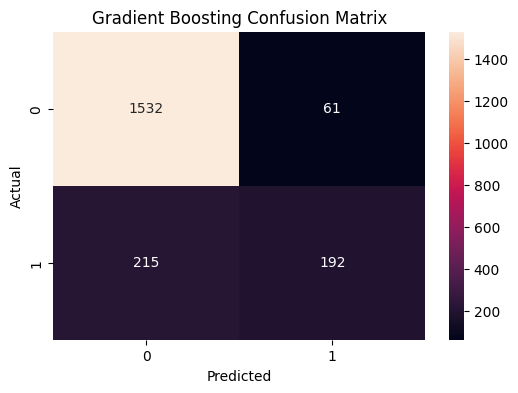

In [34]:
# GRADIENT BOOSTING PIPELINE

gb_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", GradientBoostingClassifier(

        n_estimators=200,

        learning_rate=0.05,

        max_depth=5,

        random_state=42
    ))
])

# TRAIN MODEL
gb_pipeline.fit(X_train, y_train)

# PREDICTIONS
gb_pred = gb_pipeline.predict(X_test)

# ACCURACY
print("Accuracy Score:\n")

print(
    accuracy_score(y_test, gb_pred)
)

# CLASSIFICATION REPORT
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        gb_pred
    )
)

# CONFUSION MATRIX
gb_cm = confusion_matrix(
    y_test,
    gb_pred
)

print("\nConfusion Matrix:\n")

print(gb_cm)

# CONFUSION MATRIX HEATMAP
plt.figure(figsize=(6,4))

sns.heatmap(
    gb_cm,
    annot=True,
    fmt="d"
)

plt.title("Gradient Boosting Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [35]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "Gradient Boosting"
    ],

    "Accuracy":[

        accuracy_score(y_test, lr_pred),

        accuracy_score(y_test, dt_pred),

        accuracy_score(y_test, rf_pred),

        accuracy_score(y_test, gb_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.8680
3,Gradient Boosting,0.8620
1,Decision Tree,0.8560
0,Logistic Regression,0.8305


In [36]:
joblib.dump(
    gb_pipeline,
    "final_pipeline.pkl"
)

['final_pipeline.pkl']

In [37]:
loaded_model = joblib.load(
    "final_pipeline.pkl"
)

In [38]:
sample = pd.DataFrame({

    "CreditScore":[650],

    "Geography":["France"],

    "Gender":["Male"],

    "Age":[42],

    "Tenure":[5],

    "Balance":[60000],

    "NumOfProducts":[2],

    "HasCrCard":[1],

    "IsActiveMember":[1],

    "EstimatedSalary":[50000],

    "BalancePerProduct":[20000],

    "AgeGroup":["MidAge"],

    "TenureGroup":["Medium"]
})

In [39]:
prediction = loaded_model.predict(sample)

print(prediction)

[0]
